In [3]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -----------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.model_selection import train_test_split
#split the data into train and test sets
from sklearn.linear_model import LinearRegression

In [6]:
from sklearn.metrics import mean_squared_error
#going to use mean squared error an R squared method as the evaluation matrices
from sklearn.metrics import r2_score

In [7]:
advertising=pd.DataFrame(pd.read_csv("E:\\HDSE25.1F\\ML\\Day 01\\advertising for LR.csv"))
#load the data into a dataframe

In [8]:
advertising

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### explanation of data set

TV: Advertising budget spent on TV in thousand of dollars same for the radio and newspaper as well sales of the product in thousand of units


In [9]:
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Data Inspection

Data inspection refers to the process of examining data sets ti ensure they meet specific quality criteria and to identify any patterns, anomalies or issues that needed to be addressed

In [10]:
advertising.shape

(200, 4)

In [11]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [12]:
advertising.describe()  # to obtain statistical data

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Data Cleaning

In [13]:
# checking null values and present them as a precentage
advertising.isnull().sum()*100/advertising.shape[0]

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

## Outlier Analysis

Outliers are data points that differ significantly from other observations in a dataset. They can occur due to variability in the data, measurement errors, or they might indicate something unusual or networthy. Identifyng and handling outliers is crucial in data analysis and machine learning because the can affect the results and performance of models.

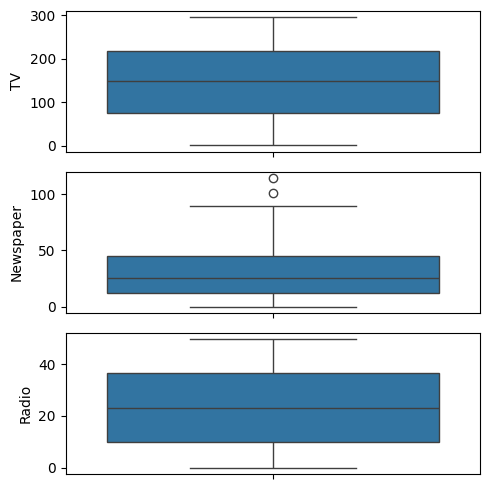

In [14]:
#Outlier Analysis
fig, axs=plt.subplots(3,figsize=(5,5))
plt1=sns.boxplot(advertising['TV'],ax=axs[0])
plt2=sns.boxplot(advertising['Newspaper'],ax=axs[1])
plt3=sns.boxplot(advertising['Radio'],ax=axs[2])
plt.tight_layout()


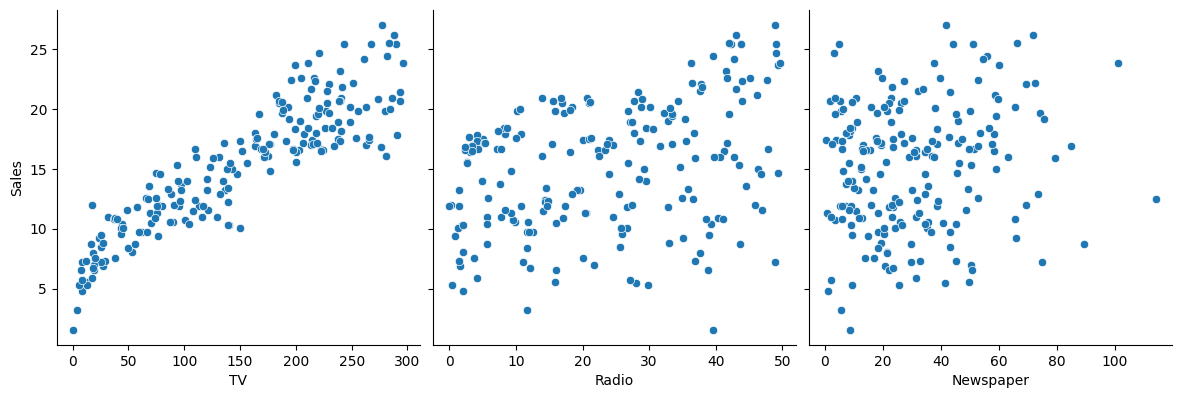

In [15]:
# let's see how sales are related with other variables using scatter plot.
sns.pairplot(advertising,x_vars=['TV','Radio','Newspaper'],
             y_vars='Sales',height=4,aspect=1,kind='scatter')
plt.show()

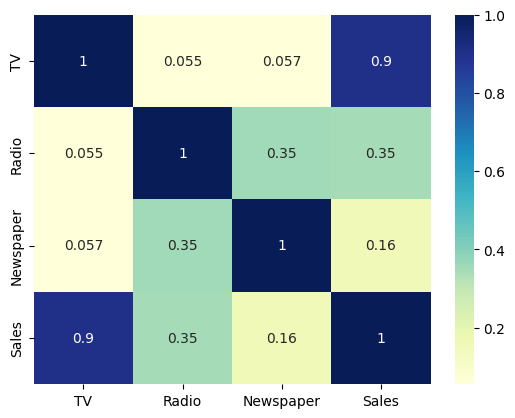

In [16]:
#let's see the correlation between the variables
sns.heatmap(advertising.corr(),cmap="YlGnBu",annot=True)
plt.show()

In [17]:
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## selecting data for dependant and independant variables

In [18]:
x=advertising.iloc[:,:3]# we are selecting upto 3rd colomn for x. that means column 0,1,2
y=advertising.iloc[:,3]# we are selecting the 3rd column only and all the rows of 3rd column
#[:,:3] - all the rows upto 3rd column
#[:,3] - all the rows and just the 3rd column

In [19]:
print (x)

        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]


In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=100)
#spilt data into train and test data
#random state decide you will get the same values

In [38]:
x_test

,TV,Radio,Newspaper
126,7.8,38.9,50.6
104,238.2,34.3,5.3
99,135.2,41.7,45.9
92,217.7,33.5,59.0
111,241.7,38.0,23.2
167,206.8,5.2,19.4
116,139.2,14.3,25.6
96,197.6,3.5,5.9
52,216.4,41.7,39.6
69,216.8,43.9,27.2


In [39]:
model=LinearRegression()
model.fit(x_train,y_train)
#import linear regression for the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
model.coef_

array([0.05373662, 0.1061416 , 0.00542157])

In [41]:
model.intercept_

np.float64(4.419176628968955)

In [43]:
x_test

,TV,Radio,Newspaper
126,7.8,38.9,50.6
104,238.2,34.3,5.3
99,135.2,41.7,45.9
92,217.7,33.5,59.0
111,241.7,38.0,23.2
167,206.8,5.2,19.4
116,139.2,14.3,25.6
96,197.6,3.5,5.9
52,216.4,41.7,39.6
69,216.8,43.9,27.2


In [44]:
y_test

126     6.6
104    20.7
99     17.2
92     19.4
111    21.8
167    17.2
116    12.2
96     16.7
52     22.6
69     22.3
164    11.9
124    19.7
182     8.7
154    20.6
125    10.6
196    14.0
194    17.3
177    16.7
163    18.0
31     11.9
11     17.4
73     11.0
15     22.4
41     17.1
97     20.5
128    24.7
133    19.6
82     11.3
139    20.7
123    15.2
83     13.6
65     11.3
151    11.6
162    19.9
170     8.4
77     14.2
32     13.2
173    16.7
174    16.5
85     20.2
Name: Sales, dtype: float64

In [45]:
y_pred=model.predict(x_test)
# obtain the predictions using the model

In [46]:
print(y_pred)

[ 9.24156185 20.88863168 16.35932288 19.99325582 21.56647985 16.18902526
 13.55593173 15.44101643 20.68858089 20.87635961 12.30666696 20.5823859
  8.2052026  16.8020073  10.49789975 10.04517517 16.27471961 14.58389375
 17.15124514 12.54217786 18.5255145  12.14739801 20.26906823 17.68550321
 16.70332653 21.47564231 20.03074293 10.79641986 19.02391131 14.77388184
 13.01107071  9.11899998 12.07692797 16.60311172  8.43700724 13.99646169
  9.96423595 14.29142558 16.80210584 17.11029489]


In [47]:
print(y_test)

126     6.6
104    20.7
99     17.2
92     19.4
111    21.8
167    17.2
116    12.2
96     16.7
52     22.6
69     22.3
164    11.9
124    19.7
182     8.7
154    20.6
125    10.6
196    14.0
194    17.3
177    16.7
163    18.0
31     11.9
11     17.4
73     11.0
15     22.4
41     17.1
97     20.5
128    24.7
133    19.6
82     11.3
139    20.7
123    15.2
83     13.6
65     11.3
151    11.6
162    19.9
170     8.4
77     14.2
32     13.2
173    16.7
174    16.5
85     20.2
Name: Sales, dtype: float64


### Evaluting the Model

In [50]:
r_squared=r2_score(y_test,y_pred) # getting the r squared value for predicted data

In [51]:
r_squared

0.8296690596780841

In [52]:
MSE = mean_squared_error(y_pred,y_test) 

In [53]:
MSE

3.3509887213291796

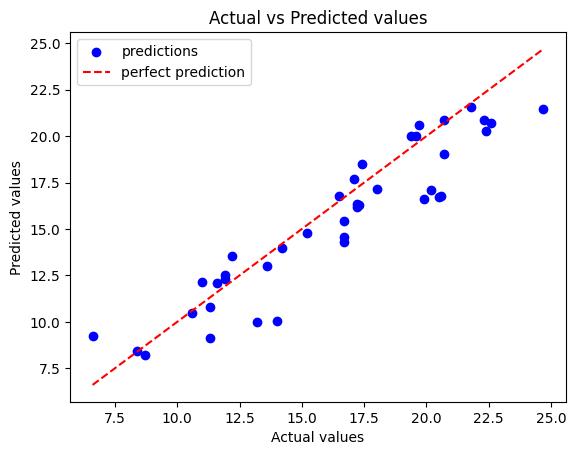

In [54]:
plt.scatter(y_test,y_pred,color='blue',label='predictions')
min_val=min(min(y_test),min(y_pred))
max_val=max(max(y_test),max(y_pred))
plt.plot([min_val,max_val],[min_val,max_val],color='red',linestyle='--',label='perfect prediction')
#plot a diagonol value for reference
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted values')
plt.legend()
plt.show()

## Finding residuals and compare

In [55]:
residuals=y_test - y_pred 

In [56]:
residuals

126   -2.641562
104   -0.188632
99     0.840677
92    -0.593256
111    0.233520
167    1.010975
116   -1.355932
96     1.258984
52     1.911419
69     1.423640
164   -0.406667
124   -0.882386
182    0.494797
154    3.797993
125    0.102100
196    3.954825
194    1.025280
177    2.116106
163    0.848755
31    -0.642178
11    -1.125514
73    -1.147398
15     2.130932
41    -0.585503
97     3.796673
128    3.224358
133   -0.430743
82     0.503580
139    1.676089
123    0.426118
83     0.588929
65     2.181000
151   -0.476928
162    3.296888
170   -0.037007
77     0.203538
32     3.235764
173    2.408574
174   -0.302106
85     3.089705
Name: Sales, dtype: float64

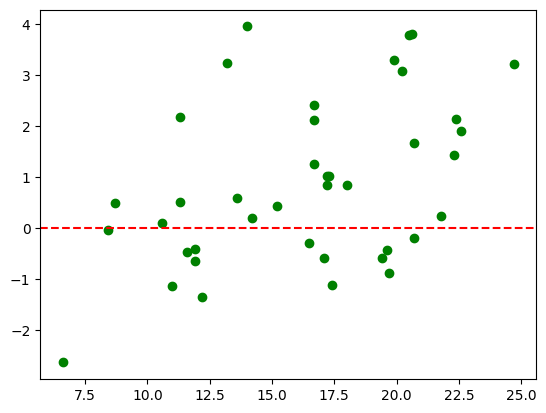

In [57]:
plt.scatter(y_test,residuals,color='green',label='residuals')
plt.axhline(y=0,color='red',linestyle='--') #add 0 line to compare residuals

## Getting a prediction

In [58]:
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [59]:
arr=np.array([230.1,37.8,69.2]).reshape(1,3) 
# we have to convert this to 2D array as out data set is 2D
# this specifies that you want to reshape the original
# 1-dimensional array into a 2-dimensional array with 1 row and 3 columns
# the shape (1,3) means 1 row and 3 columns
# this reshapes the array into 1x3 matrix (1 row and 3 columns) or you can use (1,-1)

In [60]:
model.predict(arr)  

array([21.17129883])